In [4]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv', usecols=['result']).values.ravel()  # Wait, fix: save y too!
y_test = pd.read_csv('y_test.csv', usecols=['result']).values.ravel()  # Wait, fix: save y too!
# Actually, save y during preprocess: pd.DataFrame(y_train).to_csv('y_train.csv')
# Assume you add: y_train.to_csv('y_train.csv', index=False); y_test.to_csv('y_test.csv')

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))  # ~92-95%
print(classification_report(y_test, y_pred))
joblib.dump(model, 'phish_model.pkl')


0.9669832654907282
              precision    recall  f1-score   support

          -1       0.97      0.95      0.96       956
           1       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



['phish_model.pkl']

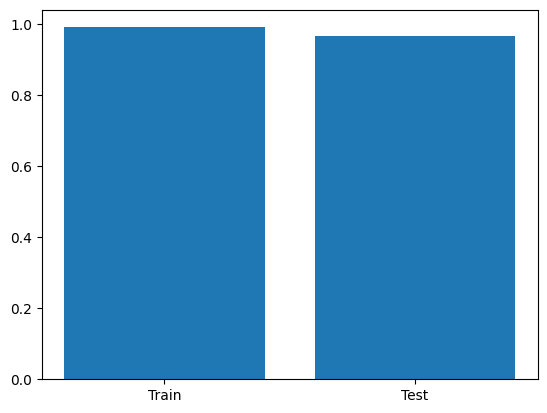

In [5]:
import matplotlib.pyplot as plt; 
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
plt.bar(['Train','Test'],[train_acc,test_acc]);
plt.savefig('acc.png')